# Outlier Detection

## What are Outliers?

An outlier is a data value that is unusually far away from most other values in a dataset.

Outliers can occur because of genuine unusual events, measurement errors, data-entry mistakes, or rare cases.

### Formula

There is no single formula for an outlier.

Common methods used to identify outliers are:

$$ \text{IQR Method} $$

and

Z-Score Method

### Numerical Example

Consider the dataset:

10, 12, 11, 13, 12, 14, 15, 100

Most values are between 10 and 15, while:

$$ 100 $$

is much larger than the other values.

Therefore, 100 may be an outlier.

### AI/ML Engineer Example

An ML engineer may find a transaction of ₹10,00,000 when most transactions are between ₹500 and ₹5,000. This unusual transaction could be a potential fraud case or a data-entry error.

In [1]:
import numpy as np

data = [10, 12, 11, 13, 12, 14, 15, 100]

mean = np.mean(data)

print("Mean:", mean)
print("Data:", data)

Mean: 23.375
Data: [10, 12, 11, 13, 12, 14, 15, 100]


The Python code stores the observations in a list and calculates their mean using np.mean(). Because the value 100 is much larger than the other observations, it pulls the mean upward. This shows why unusually large values can affect statistical calculations.

## Types of Outliers

Outliers can occur in different ways depending on the structure of the data.

The main types are global outliers, contextual outliers, and collective outliers.

### Types
1. Global Outlier

A value that is significantly different from the entire dataset.

Example:

10, 12, 11, 13, 15, 100

Here, 100 is a global outlier.

2. Contextual Outlier

A value that is unusual only in a particular context.

Example:

A temperature of 35°C may be normal in summer but unusual during winter.

3. Collective Outlier

A group of observations that is unusual when considered together.

Example:

A server normally receives 100 requests per minute, but suddenly receives thousands of requests continuously for several minutes.

### AI/ML Engineer Example

An ML engineer monitoring server traffic may identify a sudden sequence of unusual requests as a collective outlier, which could indicate a cyberattack.

In [2]:
data = [10, 12, 11, 13, 15, 100]

threshold = 50

outliers = [x for x in data if x > threshold]

print("Outliers:", outliers)

Outliers: [100]


The Python code creates a simple threshold of 50. The list comprehension checks each value and keeps only values greater than 50. Since only 100 satisfies the condition, it is identified as an outlier using this simple rule.

## Detecting Outliers

Outlier Detection is the process of identifying observations that are significantly different from the majority of the data.

Common statistical techniques include the IQR method and the Z-score method.

### Formula

Two common approaches are:

IQR Method
$$ IQR = Q_3-Q_1 $$
Z-Score Method
Z=
σ
x−μ
	​


### Numerical Example

Consider:

10, 12, 11, 13, 12, 14, 15, 100

We can use statistical methods to determine whether 100 is unusually far from the rest of the observations.

### AI/ML Engineer Example

Before training a machine-learning model, an ML engineer may detect unusually large values in features such as salary, transaction amount, age, or house price.

In [4]:
import numpy as np
from scipy.stats import zscore

data = np.array([10, 12, 11, 13, 12, 14, 15, 100])

z_scores = zscore(data)

print("Z-Scores:")
print(z_scores)

Z-Scores:
[-0.46121118 -0.39224502 -0.4267281  -0.35776194 -0.39224502 -0.32327887
 -0.28879579  2.64226592]


The Python code converts the data into a NumPy array and uses zscore() to calculate how many standard deviations each value is away from the mean. Values with unusually large positive or negative Z-scores can then be investigated as potential outliers.

## IQR Method

The IQR (Interquartile Range) Method identifies outliers using the middle 50% of the data.

An observation is commonly considered an outlier if it falls below the lower boundary or above the upper boundary.

### Formula

First calculate:

$$ IQR=Q_3-Q_1 $$

Then:

$$ \text{Lower Bound}=Q_1-1.5(IQR) $$ $$ \text{Upper Bound}=Q_3+1.5(IQR) $$

Values outside these boundaries are potential outliers.

### Numerical Example

Consider:

10, 12, 14, 15, 16, 18, 20, 50

Suppose:

$$ Q_1=13 $$

and:

$$ Q_3=19 $$

Then:

$$ IQR=19-13=6 $$

Lower bound:

$$ 13-(1.5\times6)=4 $$

Upper bound:

$$ 19+(1.5\times6)=28 $$

Therefore, values below 4 or above 28 are potential outliers.

Since:

$$ 50>28 $$

50 is an outlier.

### AI/ML Engineer Example

An ML engineer can use IQR to detect unusually large transaction amounts before training a fraud-detection or customer-spending model.

In [5]:
import numpy as np

data = np.array([10, 12, 14, 15, 16, 18, 20, 50])

Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data < lower_bound) |
    (data > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outliers:", outliers)

Q1: 13.5
Q3: 18.5
IQR: 5.0
Lower Bound: 6.0
Upper Bound: 26.0
Outliers: [50]


The Python code first calculates Q1 and Q3 using np.percentile(). It then calculates the IQR by subtracting Q1 from Q3. The lower and upper boundaries are calculated using 1.5 × IQR. Finally, the code checks which values fall outside these boundaries and identifies 50 as an outlier.

## Z-Score Method

The Z-score method measures how many standard deviations a value is away from the mean.

A common rule is that values with:

$$ |Z|>3 $$

may be considered potential outliers.

### Formula
$$ Z=\frac{x-\mu}{\sigma} $$

Where:

$x$ = Individual value
$\mu$ = Mean
$\sigma$ = Standard Deviation

### AI/ML Engineer Example

An ML engineer can use Z-scores to identify unusually high or low values in features such as age, salary, transaction value, or sensor readings.

In [6]:
from scipy.stats import zscore
import numpy as np

data = np.array([40, 45, 48, 50, 52, 55, 90])

z_scores = zscore(data)

outliers = data[np.abs(z_scores) > 2]

print("Z-Scores:", z_scores)
print("Outliers:", outliers)

Z-Scores: [-0.93633944 -0.60862064 -0.41198935 -0.28090183 -0.14981431  0.04681697
  2.3408486 ]
Outliers: [90]


The Python code calculates a Z-score for every value using zscore(). np.abs() converts negative Z-scores to their positive magnitude. The condition > 2 identifies values more than two standard deviations away from the mean. In this example, 90 is identified as a potential outlier.

## Box Plot

A Box Plot is a visualization that shows the distribution of numerical data using the minimum, Q1, median, Q3, and maximum/non-outlier values.

It is especially useful for visually identifying potential outliers.

### Formula

The box plot uses:

$$ IQR=Q_3-Q_1 $$

and the usual outlier boundaries are:

$$ Q_1-1.5(IQR) $$

and

Q
3
	​

+1.5(IQR)

### Numerical Example

Consider:

10, 12, 14, 15, 16, 18, 20, 50

The box plot will show most observations inside the main distribution, while 50 will appear separately as a potential outlier.

### AI/ML Engineer Example

An ML engineer can create box plots for numerical features such as salary, age, transaction amount, and delivery time to quickly identify extreme values.

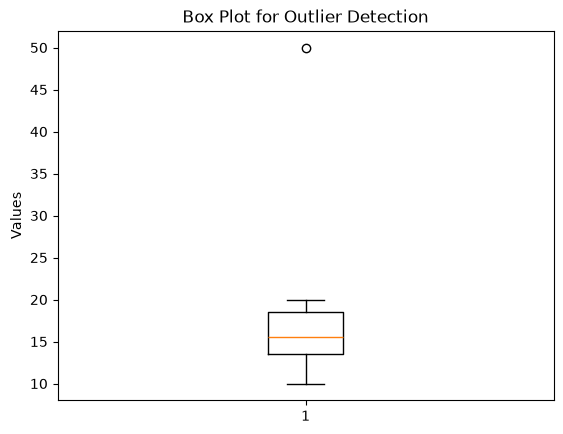

In [7]:
import matplotlib.pyplot as plt

data = [10, 12, 14, 15, 16, 18, 20, 50]

plt.boxplot(data)

plt.ylabel("Values")
plt.title("Box Plot for Outlier Detection")

plt.show()

The Python code stores the numerical data in a list and passes it to plt.boxplot(). Matplotlib calculates the quartiles and whiskers and displays the distribution. Values that fall outside the usual whisker range are displayed separately as potential outliers.

## Scatter Plot

A Scatter Plot displays individual observations as points on an X-Y coordinate system.

It is useful for finding unusual observations, relationships between variables, clusters, and possible outliers.

### Formula

A scatter plot itself does not have a specific formula.

For correlation analysis, we can use:

−1≤r≤1

### Numerical Example

Suppose we have:

Study Hours:  1   2   3   4   5   10
Marks:       50  55  60  65  70  20

The point:

$$ (10,20) $$

is far away from the other points and may be an outlier.

### AI/ML Engineer Example

An ML engineer can use a scatter plot to identify unusual observations in relationships such as house size vs price or advertising spend vs sales.

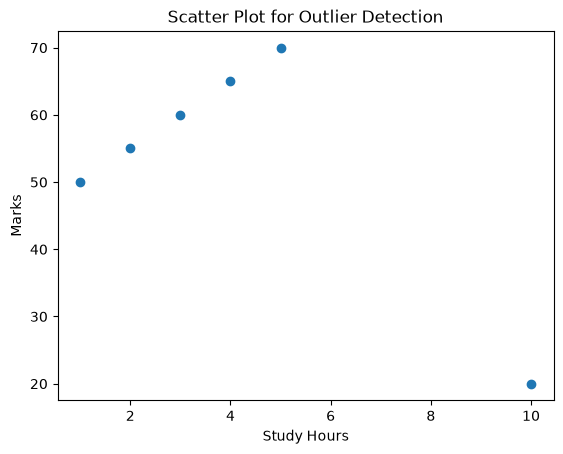

In [8]:
import matplotlib.pyplot as plt

study_hours = [1, 2, 3, 4, 5, 10]
marks = [50, 55, 60, 65, 70, 20]

plt.scatter(study_hours, marks)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Scatter Plot for Outlier Detection")

plt.show()

The Python code stores study hours and marks in separate lists. plt.scatter() plots each pair as a point. Most points form a general upward pattern, while (10, 20) is far away from the rest, making it visually identifiable as a potential outlier.